# Trackmania Monte Carlo Simulator — Exploration


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel import TournamentConfig, run_monte_carlo, REAL_PLAYERS
from tmonacodel.player import make_player_pool

sns.set_theme(style='whitegrid')

## Run simulation


In [2]:
config = TournamentConfig(n_simulations=10_000, random_seed=None)
results = run_monte_carlo(config, player_data=REAL_PLAYERS)
print(f'Simulated {config.n_simulations} seasons with {config.n_players} players')
print(f'Real players: {len(REAL_PLAYERS)}, Generic fill: {config.n_players - len(REAL_PLAYERS)}')

Simulated 10000 seasons with 128 players
Real players: 98, Generic fill: 30


## Summary table


In [3]:
df = results.summary_dataframe()
df[['name', 'country', 'mean_rank', 'median_rank', 'prob_top_N']].head(20)

,name,country,mean_rank,median_rank,prob_top_N
0,baiwack,New Zealand,63.1976,62.0,0.1306
1,Gwen,France,63.6054,63.0,0.1261
2,Birdie,Turkey,63.6678,64.0,0.1269
3,Dionysos,France,63.7054,63.0,0.1295
4,Eria,Belgium,63.8058,63.0,0.1259
5,Tona,France,63.8112,63.0,0.1292
6,J_Swag,New Zealand,63.8544,64.0,0.1285
7,neon,Poland,63.9027,64.0,0.1286
8,NiTech,Russia,63.9099,64.0,0.1299
9,Nayko,France,63.9245,64.0,0.1294


## EWC Qualifying Score (PQ)

In [4]:
pq = results.ewc_qualifying_score(top_n=8)
print(f"PQ (guaranteed top-8 qualifying score): {pq} points")

PQ (guaranteed top-8 qualifying score): 1646 points


## Qualification likelihood by score

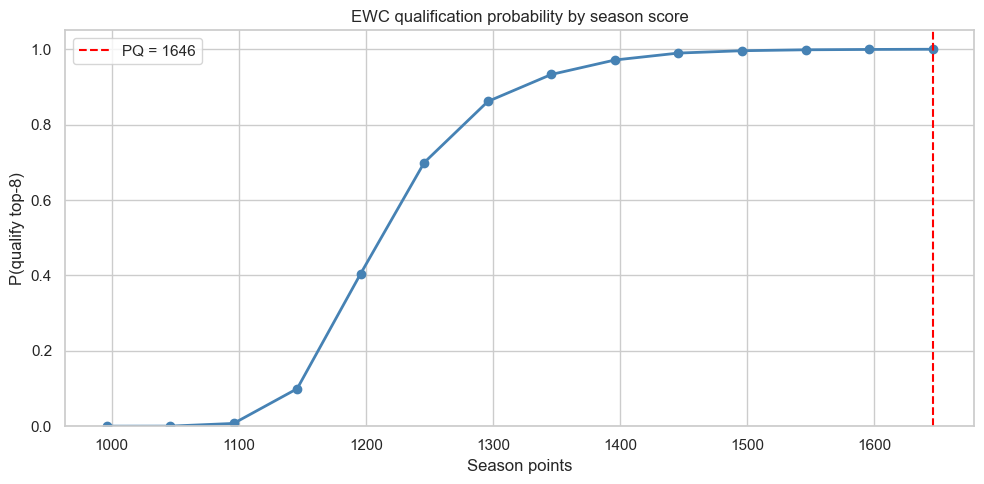

In [5]:
curve = results.ewc_qualification_curve(top_n=8, step=50)
curve_plot = curve.sort_values("score")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_plot["score"], curve_plot["prob_qualify"], marker="o", linewidth=2, color="steelblue")
ax.axvline(pq, color="red", linestyle="--", label=f"PQ = {pq}")
ax.set_xlabel("Season points")
ax.set_ylabel("P(qualify top-8)")
ax.set_title("EWC qualification probability by season score")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Minimum score to top national table

In [6]:
nation_tops = results.nation_topping_scores()
nation_tops

,country,player_count,p90_score_to_top_nation
0,France,40,2192
1,Germany,16,1920
2,Poland,14,1880
3,United Kingdom,5,1590
4,Belgium,5,1560
5,United States,4,1520
6,Turkey,4,1512
7,Russia,4,1496
8,Norway,3,1404
9,Hungary,3,1404


## Average points by finishing rank

In [7]:
rank_df = results.rank_points_profile()
print(rank_df[0:8].to_string(index=False))

 rank  mean_points  p10_points  p90_points
    1       2074.2        1692        2532
    2       1767.1        1500        2084
    3       1604.4        1376        1824
    4       1485.1        1284        1700
    5       1392.7        1232        1580
    6       1320.8        1196        1478
    7       1266.0        1170        1392
    8       1223.9        1148        1320


## Plot: Points distribution for one player


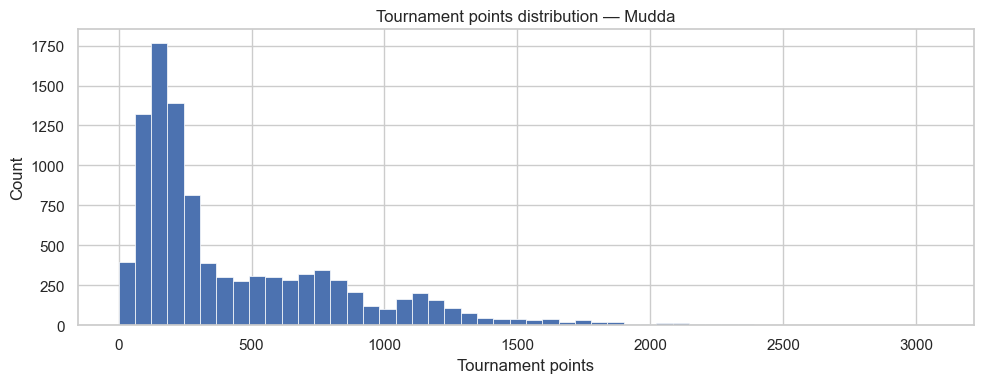

In [8]:
player_id = 0
dist = results.points_distribution(player_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist, bins=50, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Tournament points')
ax.set_ylabel('Count')
ax.set_title(f'Tournament points distribution — {results.players[player_id].name}')
plt.tight_layout()
plt.show()